In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Boxplot of Children')

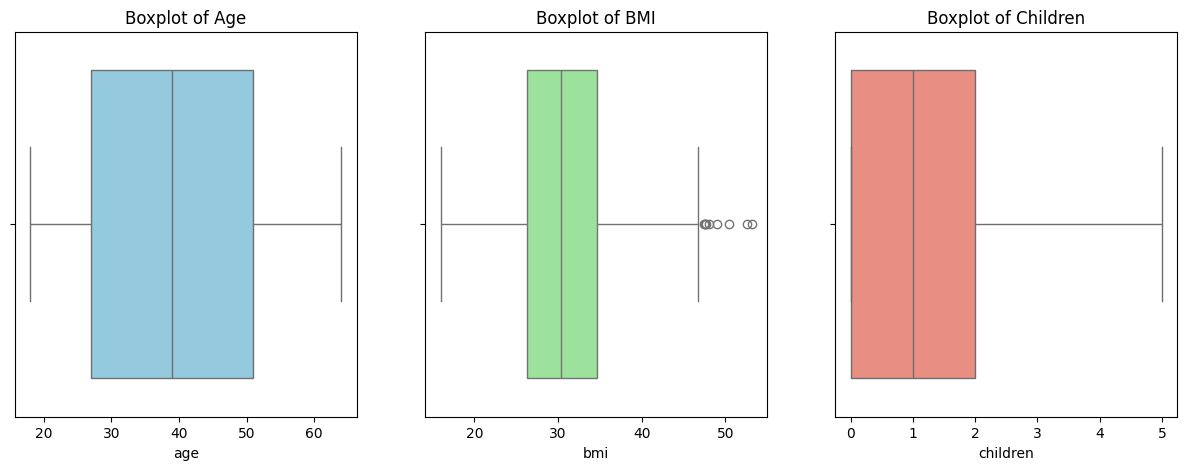

In [3]:
# Finding outliers
df = pd.read_csv('insurance.csv')
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(x=df['age'], color='skyblue')
plt.title('Boxplot of Age')

plt.subplot(1,3,2)
sns.boxplot(x=df['bmi'], color='lightgreen')
plt.title('Boxplot of BMI')

plt.subplot(1,3,3)
sns.boxplot(x=df['children'], color='salmon')
plt.title('Boxplot of Children')

In [4]:
df['bmi'].mean()+3*df['bmi'].std()

np.float64(48.957957596023604)

Text(0.5, 1.0, 'Log-Transformed Charges (Normal Distribution)')

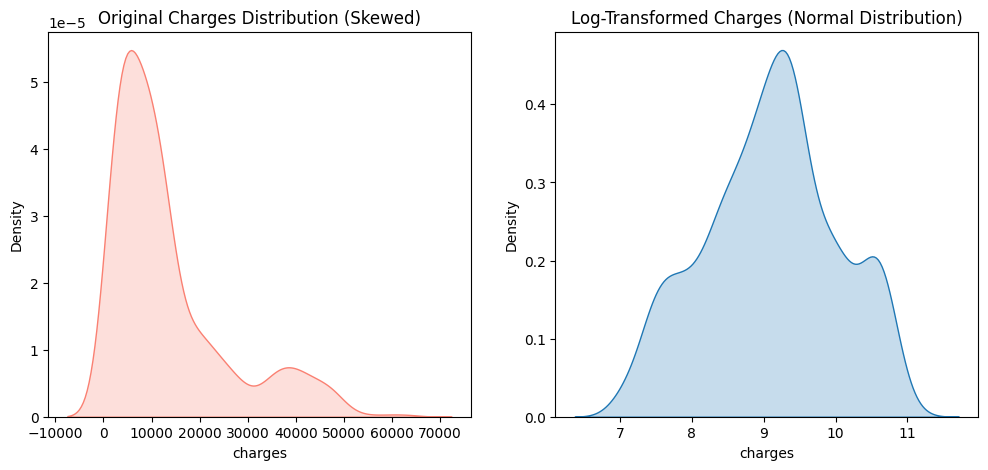

In [5]:
# KDE (Kernel Density Estimate)
import numpy as np
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.kdeplot(x=df['charges'], fill=True, color='salmon')
plt.title("Original Charges Distribution (Skewed)")

plt.subplot(1, 2, 2)
sns.kdeplot(x=np.log(df['charges']), fill=True)
plt.title("Log-Transformed Charges (Normal Distribution)")

In [6]:
# Outliers removed
outliers = df.quantile(q=.97, numeric_only=True)

df = df[(df['bmi'] < outliers['bmi'])]
df = df[(df['charges'] < outliers['charges'])] # Delete more than 0.97 threshold value
df.shape

(1262, 7)

In [7]:
# Data Preprocessing & Feature Engineering
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['bgmi'] = df['bmi']**2
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'bgmi'], dtype='object')

In [8]:
x = df.drop(['charges'], axis=1)
y = df[['charges']]
x['smoker_bmi'] = x['smoker'] * x['bmi']
x['age_smoker'] = x['age'] * x['smoker']
x = pd.get_dummies(x, drop_first=True)
x.head()

,age,sex,bmi,children,smoker,bgmi,smoker_bmi,age_smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,778.410000,27.9,19,False,False,True
1,18,1,33.770,1,0,1140.412900,0.0,0,False,True,False
2,28,1,33.000,3,0,1089.000000,0.0,0,False,True,False
3,33,1,22.705,0,0,515.517025,0.0,0,True,False,False
4,32,1,28.880,0,0,834.054400,0.0,0,True,False,False


In [9]:
x.shape

(1262, 11)

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.20)

In [11]:
# Model Building & Training
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
lr = LinearRegression()
model = lr.fit(x_train,y_train)
prediction = model.predict(x_test)
r2_score(y_test, prediction)

0.8440026443321903

In [12]:
mean_squared_error(y_test, prediction)**0.5

3993.037914260594

<Axes: xlabel='charges', ylabel='Density'>

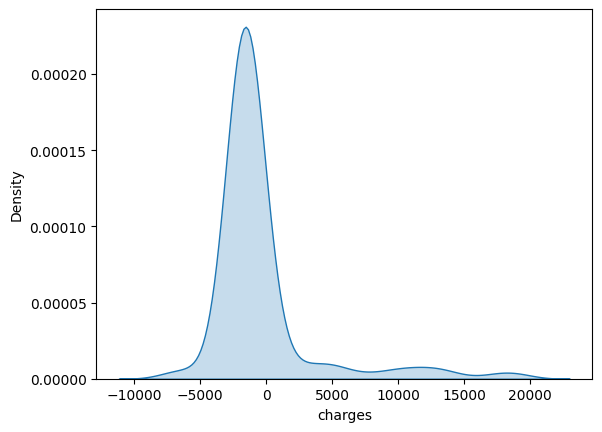

In [13]:
residuals = y_test - prediction
sns.kdeplot(x=residuals['charges'], fill=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


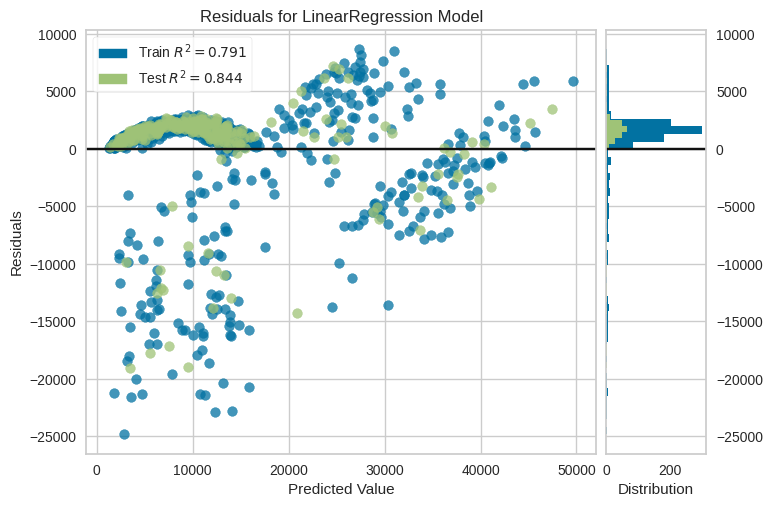

In [14]:
from yellowbrick.regressor import ResidualsPlot
vis = ResidualsPlot(model)
vis.fit(x_train, y_train)
vis.score(x_test, y_test)
vis.show();